In [25]:
import sys
sys.path.append('../..')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.patheffects as pe
import hmac


# MongoDB connection


clients = MongoClient('mongodb://localhost:27017/')
dbs = []
for db in clients.list_database_names():
    if db.startswith('r0_r1_SC_alpha'):
        dbs.append(clients[db]['destination, phase_1'])

In [26]:
dbs

[Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_15_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_1_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_25_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_2_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_35_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_3_R=0_5'), 'destination, phase_1'),
 Collec

In [27]:
pd.DataFrame(list(dbs[0].find({}))).head()

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."


/tmp/ipykernel_1887910/656628211.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  msg_cmap = mpl.cm.get_cmap(msg_cmap_name)
/tmp/ipykernel_1887910/656628211.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


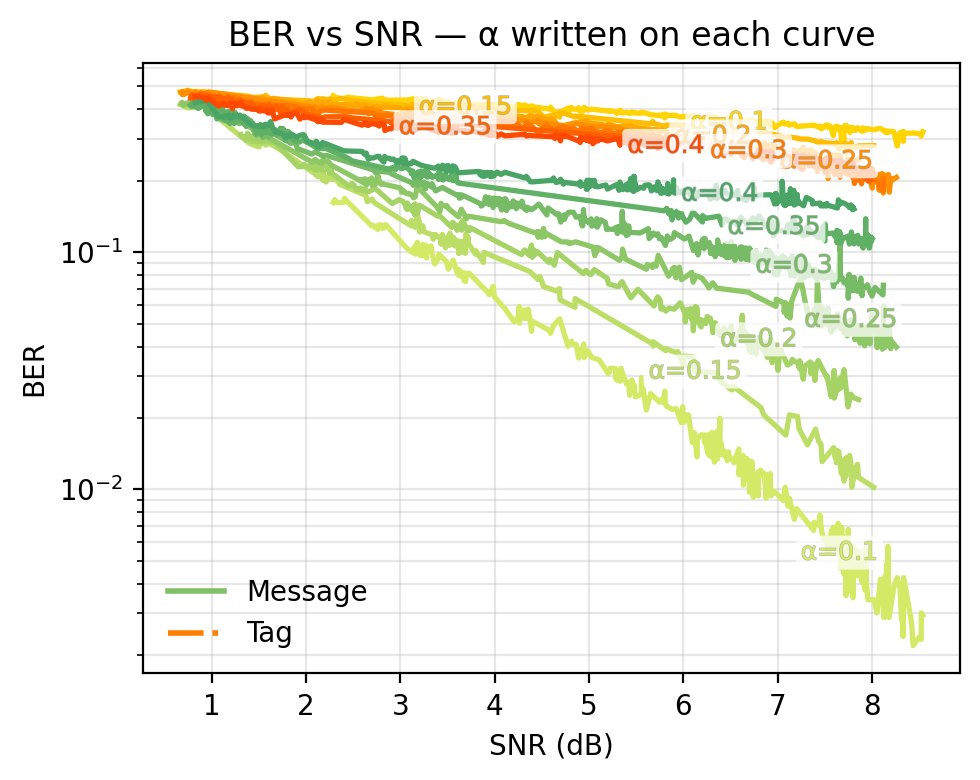

In [39]:


# --- alpha from your docs ---------------------------------------------------
def infer_alpha(coll):
    return float(coll.find_one({})["config"]["ALPHA"])

def infer_msg_tag(coll):
    temp = coll.find_one({})["config"]
    len_MAC_encoded = int(np.ceil(256/temp["MAC_REP"]/temp["MAC_LDPC"]))
    len_msg = int(np.ceil((len_MAC_encoded - 512) * temp['MSG_CODE_RATE']))
    msg_str = temp['PAYLOAD'][:len_msg//8]
    msg_encoded = cc.encode_LDPC(utils.string_to_bits(msg_str), Codeword_length=len_MAC_encoded)
    tag = hmac.new(key=temp['MAC_KEY'].encode('utf-8'),
                   msg= msg_str.encode('utf-8'),
                     digestmod=temp['MAC_SHA']).hexdigest()
    tag_bits = utils.hex_to_bits(tag)
    tag_encoded = cc.encode_LDPC(tag_bits, Codeword_length=int(np.ceil(256/temp["MAC_LDPC"])))
    tag_encoded = np.repeat(tag_encoded, int(np.ceil(1//temp["MAC_REP"])))
    return msg_encoded, tag_encoded
    
    



# --- helpers ----------------------------------------------------------------
def df_from_collection(coll):
    cur = coll.find({}, {"BER_tag": 1, "BER_msg": 1, "SNR": 1, "_id": 0})
    df = pd.DataFrame(list(cur))
    if df.empty:
        return df
    for c in ["BER_tag", "BER_msg", "SNR"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["BER_tag", "BER_msg", "SNR"])
    df = (df.groupby("SNR", as_index=False)
            .agg(BER_tag=("BER_tag","mean"), BER_msg=("BER_msg","mean"))
            .sort_values("SNR"))
    df["alpha"] = infer_alpha(coll)
    return df


def _text_on_curve(ax, x, y, text, color, frac=0.78,
                   bbox_fc="white", bbox_alpha=0.75):
    """
    Place 'text' ON the curve around the given fractional position (0..1),
    rotated to match the local slope. Adds a rounded, semi-opaque background.
    """
    if len(x) < 2:
        return
    xi = np.asarray(x); yi = np.asarray(y)
    idx = int(np.clip(frac * (len(xi)-1), 1, len(xi)-2))

    # rotation angle using log10(y) because the y-axis is logarithmic
    dy = np.log10(yi[idx+1]) - np.log10(yi[idx-1])
    dx = xi[idx+1] - xi[idx-1]
    angle = 0#np.degrees(np.arctan2(dy, dx))

    ax.text(
        xi[idx], yi[idx], text,
        color=color, fontsize=9, ha="center", va="center",
        rotation=angle, rotation_mode="anchor",
        zorder=5,
        bbox=dict(facecolor=bbox_fc, alpha=bbox_alpha,
                  edgecolor="none", boxstyle="round,pad=0.2"),
        # small halo as extra insurance against busy backgrounds
        path_effects=[pe.withStroke(linewidth=0.5, foreground="black", alpha=0.25)]
    )


def plot_ber_vs_snr_by_alpha(dbs, save_to=None,
                             msg_cmap_name='summer', tag_cmap_name="autumn"):
    series = []
    for coll in dbs:
        g = df_from_collection(coll)
        if not g.empty:
            series.append((float(g["alpha"].iloc[0]), g))
    if not series:
        print("No data to plot.")
        return

    # sort so darker (low α) are drawn first, brighter on top
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min:
        a_max = a_min + 1e-12

    norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
    msg_cmap = mpl.cm.get_cmap(msg_cmap_name)
    tag_cmap = mpl.cm.get_cmap(tag_cmap_name)

    fig, ax = plt.subplots(figsize=(5, 4), dpi= 200)


    for a, g in series:
        # invert intensity so higher α => brighter
        shade = 1.0 - norm(a)
        msg_color = msg_cmap(shade)
        tag_color = tag_cmap(shade)

        ax.plot(g["SNR"], g["BER_msg"], linestyle="-",
                linewidth=1.9, markersize=4, color=msg_color)
        ax.plot(g["SNR"], g["BER_tag"], linestyle="-",
                linewidth=1.9, markersize=4, color=tag_color)

        # write α on each line (slightly different positions to reduce overlap)
        _text_on_curve(ax, g["SNR"], g["BER_msg"], f"α={a:g}", msg_color, frac=0.78)
        _text_on_curve(ax, g["SNR"], g["BER_tag"], f"α={a:g}", tag_color, frac=0.62)

    # styling
    ax.set_yscale("log")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("BER")
    ax.set_title("BER vs SNR — α written on each curve")
    ax.grid(True, which="both", alpha=0.3)

    # tiny legend just for type
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], color=msg_cmap(0.5), lw=2, linestyle="-", label="Message"),
        Line2D([0],[0], color=tag_cmap(0.5), lw=2, linestyle="-.", label="Tag"),
    ], loc="lower left", frameon=False)

    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    # plt.xlim(left=0.5, right=4)
    # plt.ylim(bottom=5*1e-2, top=1)
    plt.show()

# Usage:
plot_ber_vs_snr_by_alpha(dbs, save_to="ber_vs_snr_alpha_on_line.png")



In [29]:
dfs = {}
for db in dbs:
    dfs[str(infer_alpha(db))] = pd.DataFrame(list(db.find({})))


In [30]:
dfs['0.15'].head()

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."


In [40]:
db.find_one({})['config']
msg_bits, tag_bits = infer_msg_tag(db)


array([0., 0., 0., ..., 0., 0., 0.])

In [32]:
from scipy.special import erfc


# Define Q-function
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))
# Error rate function
def error_rate(l, R, p):

    # Avoid log(0) issues by adding a very small number when needed.
    p = np.where(p == 0, 1e-19, p)
    one_minus_p = 1 - p
    C = 1 + p * np.log2(p) + one_minus_p * np.log2(one_minus_p)
    denom = np.log2(one_minus_p / p)
    term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)
    return qfunc(term)

In [41]:
import numpy as np

def decode_superposed_fsk(
    E0, E1, snr, sigma_n2, alpha, snr_is_db=True, return_confidence=True
):
    """
    E0, E1: 1D arrays (or lists) of per-symbol energies in f0 and f1 bins
    snr: scalar SNR for these symbols (linear or dB)
    sigma_n2: scalar noise variance per bin
    alpha: fraction of total symbol power allocated to the WEAK layer (0..1)
    snr_is_db: if True, 'snr' is in dB and will be converted to linear
    return_confidence: if True, also return a per-symbol confidence score

    Returns:
      msg_bits: np.ndarray of 0/1 (strong layer: 0=>f0, 1=>f1)
      tag_bits: np.ndarray of 0/1 (weak  layer: 0=>f0, 1=>f1)
      confidences (optional): np.ndarray in [0,1], larger => more confident
    """
    E0 = np.asarray(E0, dtype=float)
    E1 = np.asarray(E1, dtype=float)
    assert E0.shape == E1.shape

    # SNR (linear) and power model
    snr_lin = 10**(snr/10.0) if snr_is_db else float(snr)
    P_tot   = snr_lin * sigma_n2              # total signal power per symbol
    P_str   = (1.0 - alpha) * P_tot           # strong layer power
    P_weak  = alpha * P_tot                   # weak  layer power
    N       = sigma_n2                        # mean noise energy in an empty bin

    # Expected mean energies for each hypothesis (E0_hat, E1_hat)
    # H00: strong f0 + weak f0  => f0: P_tot + N,     f1: N
    # H01: strong f0 + weak f1  => f0: P_str + N,     f1: P_weak + N
    # H10: strong f1 + weak f0  => f0: P_weak + N,    f1: P_str + N
    # H11: strong f1 + weak f1  => f0: N,             f1: P_tot + N
    means = np.array([
        [P_tot + N,     N        ],  # H00
        [P_str + N,     P_weak + N],  # H01
        [P_weak + N,    P_str + N],  # H10
        [N,             P_tot + N],  # H11
    ])  # shape (4, 2)

    # For speed, compute squared errors to each hypothesis, vectorized
    # errs[h, i] = (E0[i]-means[h,0])^2 + (E1[i]-means[h,1])^2
    E = np.stack([E0, E1], axis=0)            # (2, n)
    diffs = E[None, :, :] - means[:, :, None] # (4, 2, n)
    errs  = np.sum(diffs**2, axis=1)          # (4, n)

    # Best hypothesis per symbol
    idx = np.argmin(errs, axis=0)             # (n,)
    # Map hypothesis index -> (msg_bit, tag_bit)
    # H00 -> (0,0), H01 -> (0,1), H10 -> (1,0), H11 -> (1,1)
    map_bits = np.array([[0,0],[0,1],[1,0],[1,1]])
    decoded = map_bits[idx]
    msg_bits = decoded[:,0]
    tag_bits = decoded[:,1]

    if not return_confidence:
        return msg_bits, tag_bits

    # Simple confidence: margin between best and second-best hypothesis
    sorted_errs = np.sort(errs, axis=0)       # (4, n)
    margin = sorted_errs[1] - sorted_errs[0]  # (n,)
    # Normalize margin to [0,1] for convenience (robust min-max)
    if margin.size > 0:
        lo, hi = np.percentile(margin, [5, 95])
        denom = max(hi - lo, 1e-12)
        conf = np.clip((margin - lo) / denom, 0.0, 1.0)
    else:
        conf = margin
    return msg_bits, tag_bits, conf


# ---- Example usage with one row from your DataFrame ----
# Suppose a row has: r0 (list of energies in f0), r1 (list in f1),
# SNR (likely dB), sigma_n2, and you know alpha.
row = dfs['0.15'].iloc[0]
msg, tag, conf = decode_superposed_fsk(row['r0'], row['r1'],
                                       snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                       alpha=0.15, snr_is_db=True)
msg==msg_bits, tag==tag_bits, conf

(array([ True,  True,  True, ..., False,  True,  True]),
 array([ True, False, False, ...,  True,  True, False]),
 array([1.        , 0.60817385, 0.14850291, ..., 0.08415101, 1.        ,
        0.03441516]))